# **# Text Classification and Sentiment Analysis on Amazon Reviews

## Introduction

In this assignment, I have worked on an Amazon customer review dataset to perform sentiment analysis. The main objective of this project is to classify customer reviews into two categories: Positive and Negative.

Sentiment analysis is an important Natural Language Processing task because customer reviews contain useful information about product quality, customer satisfaction, and common complaints. By analyzing reviews automatically, companies can quickly understand customer opinions and take better business decisions.

In this project, I have followed the complete machine learning workflow:
- Loading the dataset
- Cleaning and preprocessing the review text
- Performing exploratory data analysis
- Visualizing sentiment distribution and common words
- Applying TF-IDF feature extraction
- Training machine learning models
- Evaluating the model using accuracy, F1-score, confusion matrix, and classification report*

# **Importing the Required libraries **

In [3]:
# Installing required library for word cloud
!pip install wordcloud -q

# Importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string

# Word cloud and text processing
from wordcloud import WordCloud
from collections import Counter

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

## Library Import

In this step, I imported all the required Python libraries. Pandas and NumPy are used for data handling, Matplotlib is used for visualization, WordCloud is used for generating word clouds, and Scikit-learn is used for machine learning model development and evaluation.

# **Load Dataset**

In [4]:
# Loading the TSV dataset
df = pd.read_csv("/content/drive/MyDrive/ASSIGNMENTS/NLP/amazonreviews.tsv", sep="\t")

# Display first 5 rows
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


## Dataset Loading

The dataset was loaded using Pandas. Since the file is in TSV format, I used tab separation while reading the file. The dataset contains Amazon product reviews along with their sentiment labels.

# **Basic Dataset Information**

In [5]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

# Dataset information
df.info()

Dataset Shape: (10000, 2)
Columns: ['label', 'review']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [6]:
# Checking first few records
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


## Dataset Overview

The dataset contains 10,000 records and 2 columns. The first column is `label`, which represents the sentiment of the review as positive or negative. The second column is `review`, which contains the actual customer review text.

This shows that the dataset is suitable for a binary text classification problem.

# **Check Missing Values and Duplicates**

In [8]:
# Checking missing values
df.isnull().sum()

,0
label,0
review,0


In [9]:
# Checking duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Missing Values and Duplicate Check

In this step, I checked whether the dataset contains missing values or duplicate rows. Missing reviews can affect text preprocessing and model training, so it is important to check them before building the model.

In this dataset, there are no missing values and no duplicate records, so the data is already clean at the basic level.

# **Sentiment Distribution**

In [10]:
# Checking label distribution
df['label'].value_counts()

,count
label,
neg,5097
pos,4903


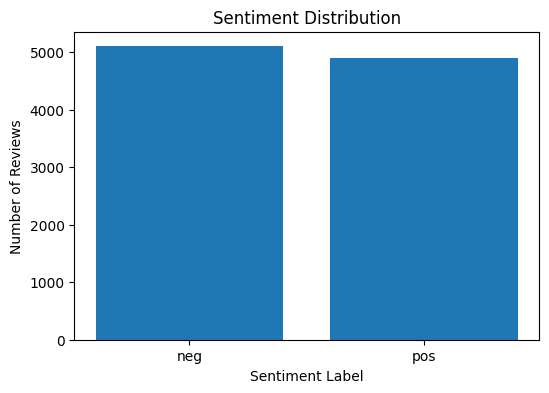

In [11]:
# Plotting sentiment distribution
label_counts = df['label'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Reviews")
plt.show()

## Sentiment Distribution

The sentiment distribution shows how many reviews belong to positive and negative classes. This is important because if the dataset is highly imbalanced, the model may become biased toward the majority class.

Here, the dataset is almost balanced, which is good for training a sentiment classification model.

# **Text Cleaning Function**

In [12]:
# Function for cleaning review text
def clean_text(text):
    text = str(text).lower()                         # convert text to lowercase
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"<.*?>", "", text)               # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)            # remove punctuation, numbers, special characters
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces

    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]

    return " ".join(words)

# Applying text cleaning
df['clean_review'] = df['review'].apply(clean_text)

# Display original and cleaned reviews
df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning nongamer sound track beautiful paints ...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack im reading lot reviews saying ...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


## Text Preprocessing

Text preprocessing is an important step in Natural Language Processing. Raw customer reviews may contain capital letters, punctuation, numbers, special characters, HTML tags, and unnecessary words.

In this step, I cleaned the review text by:
- Converting text into lowercase
- Removing URLs and HTML tags
- Removing punctuation, numbers, and special characters
- Removing extra spaces
- Removing common English stopwords

This cleaned text is more useful for feature extraction and model training.

# **Review Length Analysis**

In [13]:
# Creating review length column
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

# Display basic statistics
df['review_length'].describe()

,review_length
count,10000.000000
mean,36.056300
std,19.544353
min,4.000000
25%,20.000000
50%,32.000000
75%,49.000000
max,132.000000


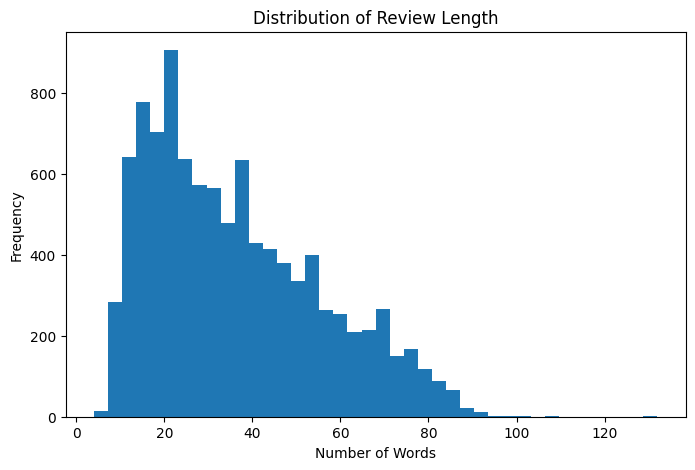

In [14]:
# Plot review length distribution
plt.figure(figsize=(8, 5))
plt.hist(df['review_length'], bins=40)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## Review Length Analysis

Review length analysis helps in understanding how long customer reviews are after cleaning. Some reviews are short and direct, while some reviews contain detailed opinions.

This step helps us understand the structure of the text data before applying machine learning models.

# **Word Cloud for Positive Reviews**

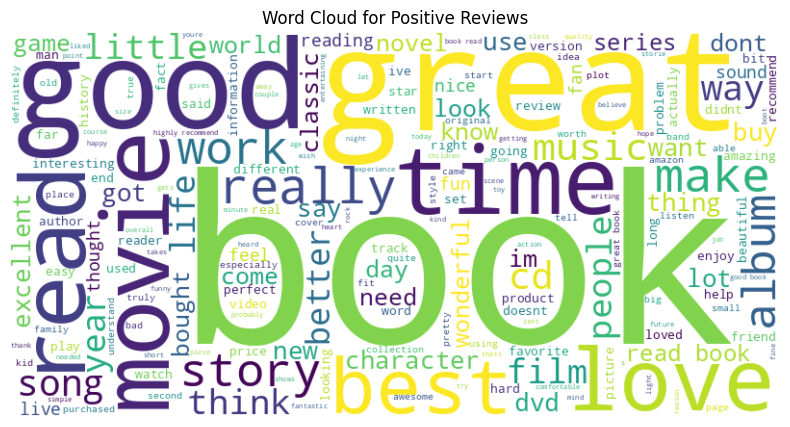

In [15]:
# Combining all positive reviews
positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])

# Creating word cloud
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Positive Reviews")
plt.show()

## Word Cloud for Positive Reviews

The positive word cloud shows the most frequently occurring words in positive customer reviews. Larger words appear more frequently.

This helps in understanding what customers commonly mention when they are satisfied with a product.

# **Word Cloud for Negative Reviews**

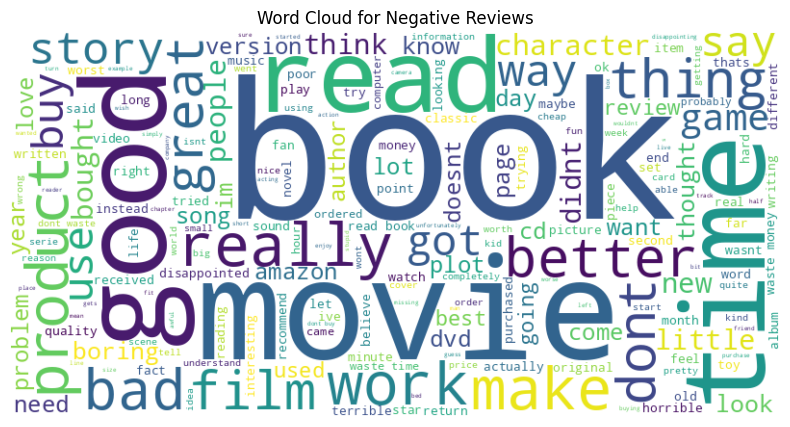

In [16]:
# Combining all negative reviews
negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

# Creating word cloud
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Negative Reviews")
plt.show()

## Word Cloud for Negative Reviews

The negative word cloud shows the most common words used in negative reviews. This is useful for identifying common complaints or dissatisfaction patterns among customers.

Companies can use this type of analysis to find product issues and improve customer satisfaction.

# **Most Common Positive and Negative Words**

In [17]:
# Function to get most common words
def get_common_words(text_data, n=20):
    all_words = " ".join(text_data).split()
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

# Most common words in positive reviews
positive_common_words = get_common_words(df[df['label'] == 'pos']['clean_review'], 20)

# Most common words in negative reviews
negative_common_words = get_common_words(df[df['label'] == 'neg']['clean_review'], 20)

print("Most Common Positive Words:")
print(positive_common_words)

print("\nMost Common Negative Words:")
print(negative_common_words)

Most Common Positive Words:
[('book', 3313), ('great', 2087), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('just', 1022), ('love', 902), ('time', 871), ('really', 827), ('best', 801), ('story', 713), ('cd', 581), ('music', 559), ('books', 548), ('dont', 531), ('little', 523), ('think', 508), ('recommend', 490), ('album', 485)]

Most Common Negative Words:
[('book', 3184), ('like', 1547), ('just', 1507), ('movie', 1465), ('dont', 1240), ('read', 1187), ('good', 1134), ('time', 1034), ('buy', 814), ('really', 778), ('bad', 749), ('money', 744), ('did', 671), ('better', 656), ('great', 632), ('story', 621), ('product', 620), ('work', 609), ('didnt', 573), ('im', 537)]


In [18]:
# Convert common words to dataframe
positive_words_df = pd.DataFrame(positive_common_words, columns=['Word', 'Frequency'])
negative_words_df = pd.DataFrame(negative_common_words, columns=['Word', 'Frequency'])

positive_words_df.head()

,Word,Frequency
0,book,3313
1,great,2087
2,good,1635
3,read,1553
4,like,1268


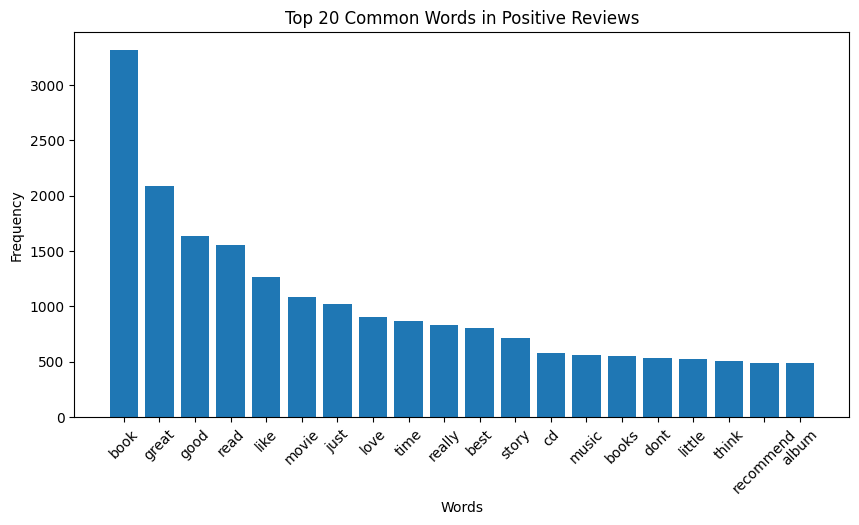

In [19]:
# Plot common positive words
plt.figure(figsize=(10, 5))
plt.bar(positive_words_df['Word'], positive_words_df['Frequency'])
plt.title("Top 20 Common Words in Positive Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

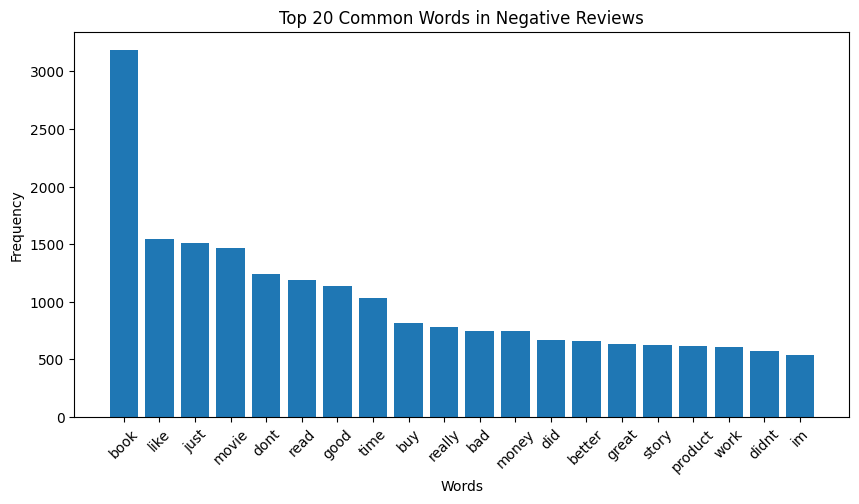

In [20]:
# Plot common negative words
plt.figure(figsize=(10, 5))
plt.bar(negative_words_df['Word'], negative_words_df['Frequency'])
plt.title("Top 20 Common Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

## Most Common Words

In this step, I identified the most common words in positive and negative reviews separately. This gives a better understanding of the words frequently used by satisfied and dissatisfied customers.

Common word analysis is useful in sentiment analysis because it gives initial insights into customer opinions before model building.

# **Convert Labels into Numeric Format**

In [21]:
# Mapping labels to numeric values
df['sentiment'] = df['label'].map({'neg': 0, 'pos': 1})

# Checking result
df[['label', 'sentiment']].head()

,label,sentiment
0,pos,1
1,pos,1
2,pos,1
3,pos,1
4,pos,1


## Label Encoding

Machine learning models work with numeric values. Therefore, I converted the sentiment labels into numeric format.

Here:
- Negative reviews are represented as 0
- Positive reviews are represented as 1

This makes the target variable suitable for machine learning classification.

# **Train-Test Split**

In [22]:
# Features and target variable
X = df['clean_review']
y = df['sentiment']

# Splitting dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000,)
Testing Data: (2000,)


## Train-Test Split

The dataset was divided into training and testing sets. The training data is used to train the machine learning model, while the testing data is used to check how well the model performs on unseen reviews.

I used 80% data for training and 20% data for testing. Stratified splitting was used so that both positive and negative classes remain properly distributed in training and testing sets.

# **TF-IDF Feature Extraction with Logistic Regression**

In [23]:
# Creating TF-IDF + Logistic Regression pipeline
logistic_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('model', LogisticRegression(max_iter=1000))
])

# Training the model
logistic_model.fit(X_train, y_train)

# Prediction
y_pred_lr = logistic_model.predict(X_test)

# Evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Logistic Regression F1 Score:", f1_lr)

Logistic Regression Accuracy: 0.848
Logistic Regression F1 Score: 0.8439425051334702


## TF-IDF and Logistic Regression Model

TF-IDF stands for Term Frequency-Inverse Document Frequency. It converts text data into numeric features by giving importance to meaningful words.

I used TF-IDF with unigram and bigram features. After feature extraction, I trained a Logistic Regression model. Logistic Regression is commonly used for binary classification problems and works well for text classification tasks.

# **Compare Multiple Models**

In [24]:
# Defining multiple machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB()
}

# Training and evaluating each model
results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append([model_name, accuracy, f1])

# Creating results dataframe
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8480,0.843943
1,Linear SVM,0.8415,0.839980
2,Naive Bayes,0.8445,0.840103


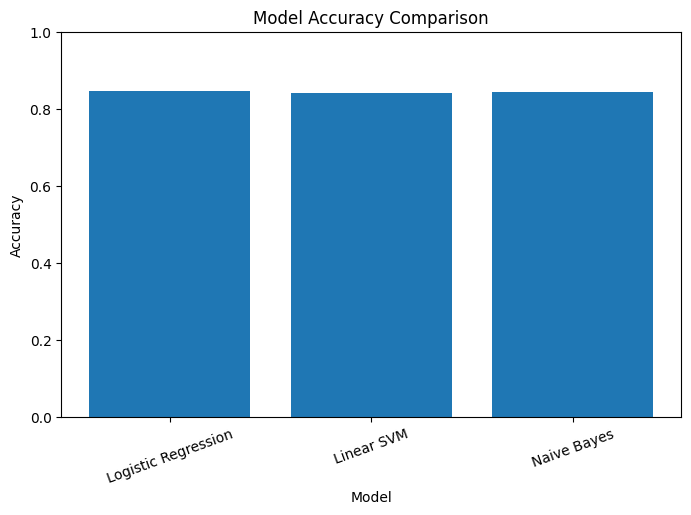

In [25]:
# Plotting model comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## Model Comparison

In this step, I compared three different machine learning models:
- Logistic Regression
- Linear Support Vector Machine
- Multinomial Naive Bayes

All models were trained using TF-IDF features. Accuracy and F1-score were used for comparison. F1-score is important because it considers both precision and recall.

#**Final Model Evaluation**




In [26]:
# Selecting Logistic Regression as final model
final_model = logistic_model

# Final predictions
final_predictions = final_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, final_predictions)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, final_predictions, target_names=["Negative", "Positive"]))

Confusion Matrix:
[[874 145]
 [159 822]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.85      1019
    Positive       0.85      0.84      0.84       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



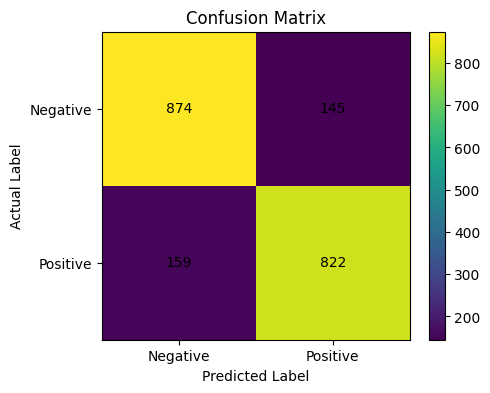

In [27]:
# Plot confusion matrix manually
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## Final Model Evaluation

The final model was evaluated using a confusion matrix and classification report.

The confusion matrix shows:
- Correctly predicted negative reviews
- Correctly predicted positive reviews
- Negative reviews incorrectly predicted as positive
- Positive reviews incorrectly predicted as negative

The classification report gives precision, recall, F1-score, and support for both classes. These metrics provide a detailed understanding of the model performance.

# **Cross Validation**

In [28]:
# Cross validation using Logistic Regression pipeline
cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Average Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.852  0.8325 0.8325 0.8305 0.8495]
Average Cross Validation Accuracy: 0.8394


## Cross Validation

Cross validation was performed to check the robustness of the model. Instead of evaluating the model only once, cross validation divides the dataset into multiple parts and trains/tests the model multiple times.

The average cross validation accuracy gives a more reliable estimate of model performance.

# **Test Model with Custom Reviews**

In [29]:
# Testing model with custom reviews
sample_reviews = [
    "This product is amazing and works perfectly.",
    "Very bad quality, I am disappointed with this purchase.",
    "The product is okay but delivery was late.",
    "Excellent product, I would definitely recommend it."
]

sample_predictions = final_model.predict(sample_reviews)

for review, prediction in zip(sample_reviews, sample_predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 50)

Review: This product is amazing and works perfectly.
Predicted Sentiment: Positive
--------------------------------------------------
Review: Very bad quality, I am disappointed with this purchase.
Predicted Sentiment: Negative
--------------------------------------------------
Review: The product is okay but delivery was late.
Predicted Sentiment: Positive
--------------------------------------------------
Review: Excellent product, I would definitely recommend it.
Predicted Sentiment: Positive
--------------------------------------------------


## Testing on Custom Reviews

After training and evaluating the model, I tested it on some custom reviews. This step helps in understanding how the model predicts sentiment for new review text.

The model predicts whether a new customer review is positive or negative based on the patterns learned from the training dataset.

# **Final Conclusion**

# Conclusion

In this assignment, I successfully performed sentiment analysis on Amazon customer reviews. The dataset contained review text and sentiment labels. I first loaded and explored the dataset, then checked for missing values and duplicate records.

After that, I cleaned the review text by converting it into lowercase, removing unnecessary characters, and removing stopwords. Exploratory data analysis was performed using sentiment distribution, review length analysis, word clouds, and common word frequency analysis.

For model development, I used TF-IDF feature extraction and trained different machine learning models such as Logistic Regression, Linear SVM, and Naive Bayes. The models were evaluated using accuracy, F1-score, confusion matrix, and classification report.

From the results, Logistic Regression performed well for this binary sentiment classification task. The model can be used to automatically classify Amazon customer reviews as positive or negative. This type of system can help companies monitor customer satisfaction, detect negative feedback quickly, and improve product quality based on customer opinions.

#**Result**

The Logistic Regression model achieved **84.8% accuracy** and **84.39% F1-score** on the test data. This shows that the model performed well and was able to classify most Amazon reviews correctly as Positive or Negative.

Therefore, TF-IDF with Logistic Regression is a suitable approach for this sentiment analysis task.